<h2 style="color:green;text-align:center;font-weight:bold">Project ID : PRCP-1021 - Insurance Cost Prediction</h2>

---


**`Business Objective`**

**Problem** : Predicting medical insurance charges based on customer demographic and health-related features.

**ML Type Problem** : <span style="color:violet">Regression</span>

**Target Variable** : `charges`

**Model Evaluation** : Mean-absolute Error **(MAE)**, Mean-squared Error **(MSE)**, Root Mean Squared Error **(RMSE)**, R-Square **(R²)**


**`Domain Analysis`**

| Feature | Domain meaning | Expected relationship with charges |
|---|---|---|
| `age` | Age of the insured person | Generally increases |
| `sex` | Gender of the insured person | May have a smaller effect |
| `bmi` | Body Mass Index | May increase with higher BMI |
| `children` | Number of dependents | May affect premium/cost |
| `smoker` | Smoking status | Often strongly associated with higher charges |
| `region` | Residential region | May have a regional effect |
| `charges` | Medical insurance cost | **Target variable** |


### 📁 Importing Required Libraries


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
%matplotlib inline

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)

plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')


In [2]:
# Loading the dataset
df = pd.read_csv('datasets_13720_18513_insurance.csv')

# Sample view
df.sample(min(10, len(df)), random_state=42)


,age,sex,bmi,children,smoker,region,charges
764,45,female,25.175,2,no,northeast,9095.06825
887,36,female,30.020,0,no,northwest,5272.17580
890,64,female,26.885,0,yes,northwest,29330.98315
1293,46,male,25.745,3,no,northwest,9301.89355
259,19,male,31.920,0,yes,northwest,33750.29180
1312,34,male,42.900,1,no,southwest,4536.25900
899,19,female,22.515,0,no,northwest,2117.33885
752,64,male,37.905,0,no,northwest,14210.53595
1286,28,female,17.290,0,no,northeast,3732.62510
707,49,male,28.690,3,no,northwest,10264.44210


**`🧩 Data Validation`**

---


**🔢 Numerical Columns Data Validation**


In [3]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print(f'Number of Numerical Columns: {len(numerical_columns)}\n')

for col in numerical_columns:
    print(
        f'{col:12s} → DType: {df[col].dtype} | '
        f'NUnique: {df[col].nunique()} | '
        f'Range: [{df[col].min()} → {df[col].max()}]'
    )


Number of Numerical Columns: 4

age          → DType: int64 | NUnique: 47 | Range: [18 → 64]
bmi          → DType: float64 | NUnique: 548 | Range: [15.96 → 53.13]
children     → DType: int64 | NUnique: 6 | Range: [0 → 5]
charges      → DType: float64 | NUnique: 1337 | Range: [1121.8739 → 63770.42801]


---
**📊 Categorical Columns Validation**


In [4]:
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print(f'Number of Categorical Columns: {len(categorical_columns)}\n')

for col in categorical_columns:
    mode_value = df[col].mode().iloc[0] if not df[col].mode().empty else None
    print(
        f'{col:12s} → DType: {df[col].dtype} | '
        f'NUnique: {df[col].nunique()} | Mode: {mode_value} | '
        f'Unique: {df[col].unique()}'
    )


Number of Categorical Columns: 3

sex          → DType: object | NUnique: 2 | Mode: male | Unique: ['female' 'male']
smoker       → DType: object | NUnique: 2 | Mode: no | Unique: ['yes' 'no']
region       → DType: object | NUnique: 4 | Mode: southeast | Unique: ['southwest' 'southeast' 'northwest' 'northeast']


**`📊 Complete Data Analysis Report`**

---


In [5]:
rows, cols = df.shape

print(f'✅ Shape of Dataset: {rows:,} Rows × {cols:,} Columns')
print(f'Size of DataFrame: {df.size:,}')
print(f'Memory Usage: {df.memory_usage(deep=True).sum()/(1024**2):.2f} MB')

print('\n' + '='*50)
print('🏃 Data Types:')
print(df.dtypes)

print('\n' + '='*50)
print('⭕ Missing Values:')
missing_count = df.isnull().sum()
missing_pct = (missing_count / rows) * 100

missing_report = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_Percentage': missing_pct.round(2)
}).sort_values('Missing_Count', ascending=False)

display(missing_report)

print('\n' + '='*50)
print(f'🔁 Duplicate Rows: {df.duplicated().sum()}')


✅ Shape of Dataset: 1,338 Rows × 7 Columns
Size of DataFrame: 9,366
Memory Usage: 0.25 MB

🏃 Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

⭕ Missing Values:


,Missing_Count,Missing_Percentage
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0



🔁 Duplicate Rows: 1


**Decision Insight**

- Check whether missing values are present before modeling.
- Duplicate records should be removed if they represent repeated observations.
- Categorical columns need encoding before they can be used by most ML models.


In [6]:
# Remove duplicate rows
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print('Remaining duplicate rows:', df.duplicated().sum())
print('Updated shape:', df.shape)


Remaining duplicate rows: 0
Updated shape: (1337, 7)


In [7]:
print('🥡 Statistical Summary - Numerical Columns')
display(df.describe().transpose().round(2))

print('\n🥡 Statistical Summary - Categorical Columns')
display(df.describe(include='object').transpose())


🥡 Statistical Summary - Numerical Columns


,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.22,14.04,18.00,27.00,39.00,51.00,64.00
bmi,1337.0,30.66,6.10,15.96,26.29,30.40,34.70,53.13
children,1337.0,1.10,1.21,0.00,0.00,1.00,2.00,5.00
charges,1337.0,13279.12,12110.36,1121.87,4746.34,9386.16,16657.72,63770.43



🥡 Statistical Summary - Categorical Columns


,count,unique,top,freq
sex,1337,2,male,675
smoker,1337,2,no,1063
region,1337,4,southeast,364


<h3 style="color:orange;font-weight:bold;text-align:center">Task 1:- Prepare a complete data analysis report on the given data.</h3>

- Identify dataset shape, data types, missing values, and duplicate records.
- Understand numerical and categorical features.
- Analyze the target variable `charges`.
- Perform exploratory data analysis before model building.


---
**`🎯 Target Variable Analysis`**


Target Variable : charges

Mean     : 13279.12
Median   : 9386.16
Std      : 12110.36
Skewness : 1.52
Range    : [1121.87 → 63770.43]


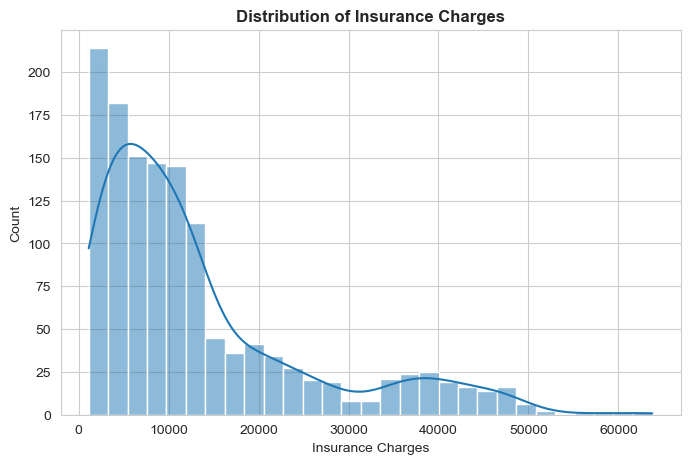

In [8]:
print('Target Variable : charges\n')
print(f"Mean     : {df['charges'].mean():.2f}")
print(f"Median   : {df['charges'].median():.2f}")
print(f"Std      : {df['charges'].std():.2f}")
print(f"Skewness : {df['charges'].skew():.2f}")
print(f"Range    : [{df['charges'].min():.2f} → {df['charges'].max():.2f}]")

plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Insurance Charges', fontweight='bold')
plt.xlabel('Insurance Charges')
plt.ylabel('Count')
plt.show()


**Decision Insight**

The target distribution should be checked for skewness and extreme values. A right-skewed insurance-cost distribution is common in this type of dataset, so the model evaluation should be interpreted together with MAE, RMSE, and R².


---
**`🎃 Exploratory Data Analysis`**


**🔢 Numerical Columns Analysis**


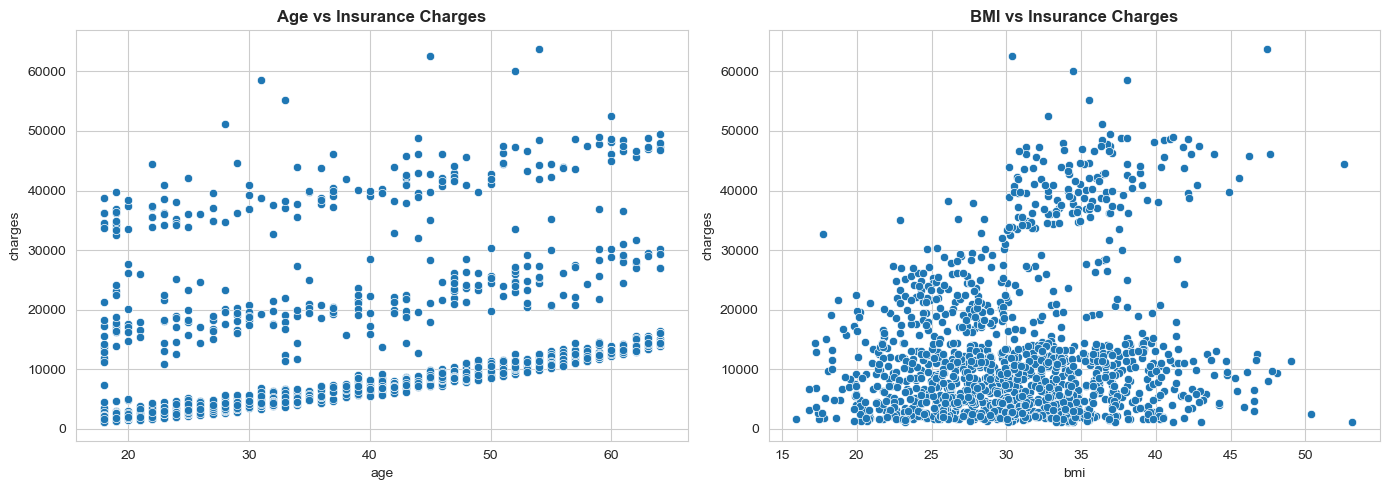

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='age', y='charges', data=df, ax=axes[0])
axes[0].set_title('Age vs Insurance Charges', fontweight='bold')

sns.scatterplot(x='bmi', y='charges', data=df, ax=axes[1])
axes[1].set_title('BMI vs Insurance Charges', fontweight='bold')

plt.tight_layout()
plt.show()


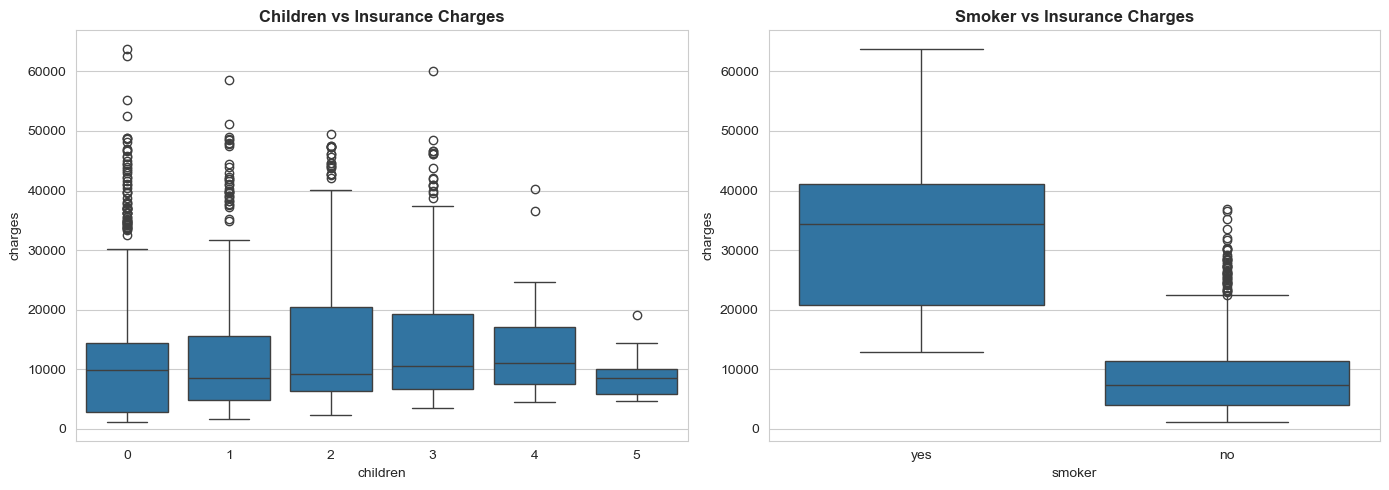

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='children', y='charges', data=df, ax=axes[0])
axes[0].set_title('Children vs Insurance Charges', fontweight='bold')

sns.boxplot(x='smoker', y='charges', data=df, ax=axes[1])
axes[1].set_title('Smoker vs Insurance Charges', fontweight='bold')

plt.tight_layout()
plt.show()


**🌍 Categorical Columns Analysis**


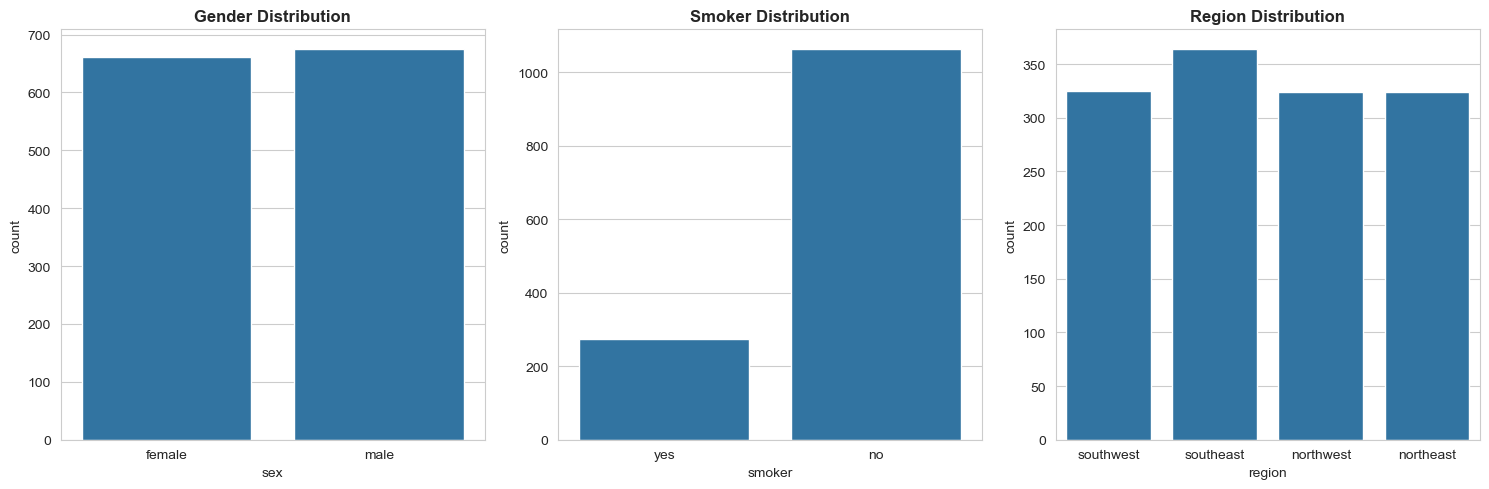

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(x='sex', data=df, ax=axes[0])
axes[0].set_title('Gender Distribution', fontweight='bold')

sns.countplot(x='smoker', data=df, ax=axes[1])
axes[1].set_title('Smoker Distribution', fontweight='bold')

sns.countplot(x='region', data=df, ax=axes[2])
axes[2].set_title('Region Distribution', fontweight='bold')

plt.tight_layout()
plt.show()


---
**`⭕ Handling Missing Values`**


In [12]:
missing_report = df.isnull().sum().to_frame('Missing_Count')
missing_report['Missing_Percentage'] = (missing_report['Missing_Count'] / len(df) * 100).round(2)
display(missing_report[missing_report['Missing_Count'] > 0])

# Safe imputation if missing values exist
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode().iloc[0])

print('Total remaining missing values:', df.isnull().sum().sum())


,Missing_Count,Missing_Percentage


Total remaining missing values: 0


---
**`⭕ Handling Multicollinearity and Numerical Columns Correlation with charges`**


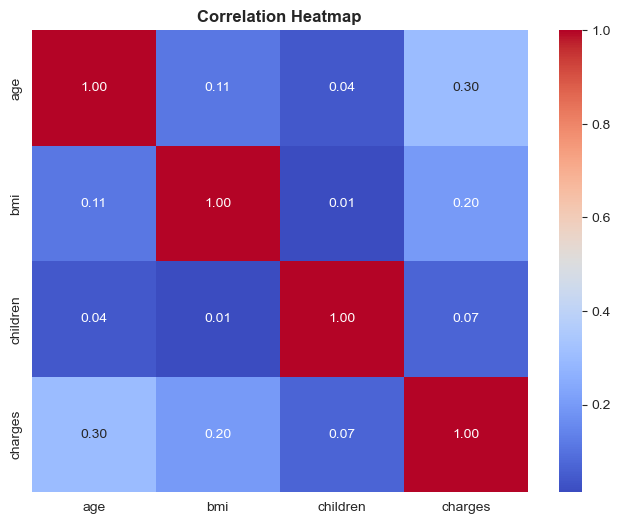

Correlation with charges:


,Correlation
charges,1.000000
age,0.298308
bmi,0.198401
children,0.067389


In [13]:
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontweight='bold')
plt.show()

print('Correlation with charges:')
display(corr['charges'].sort_values(ascending=False).to_frame('Correlation'))


---
**`🟢 Outliers Analysis`**


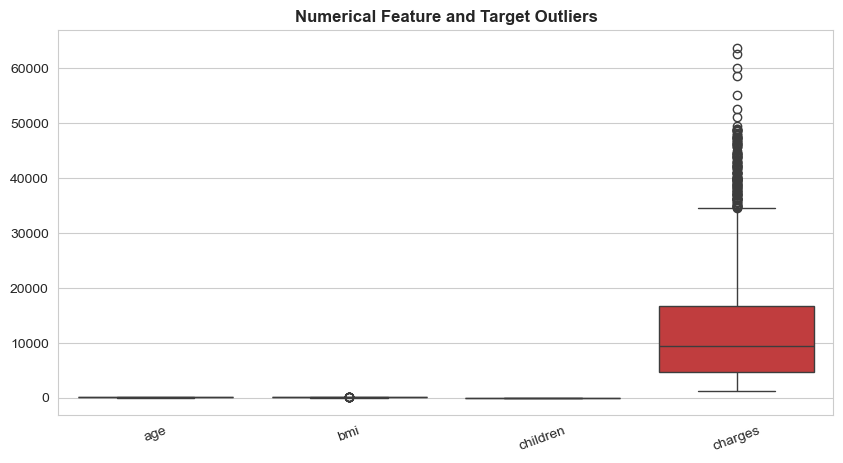

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['age', 'bmi', 'children', 'charges']])
plt.title('Numerical Feature and Target Outliers', fontweight='bold')
plt.xticks(rotation=20)
plt.show()


**Decision Insight**

Outliers are reviewed rather than automatically deleted. In insurance-cost prediction, unusually high charges can represent real customers and may contain useful information for the regression problem.


---
**`🤖 Feature Engineering`**


In [15]:
# Create a copy for modeling
model_df = df.copy()

# Encode categorical variables
model_df = pd.get_dummies(
    model_df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True,
    dtype=int
)

display(model_df.head())
print('Modeling columns:')
print(model_df.columns.tolist())


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


Modeling columns:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


---
**`⚽ Feature Selection`**


In [16]:
X = model_df.drop('charges', axis=1)
y = model_df['charges']

print('Features:')
print(X.columns.tolist())
print('\nTarget:', y.name)


Features:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

Target: charges


---
**`🎯 Model Building`**


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)


X_train: (1069, 8)
X_test : (268, 8)
y_train: (1069,)
y_test : (268,)


In [18]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

model_comparison = []

def model_evaluation(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return r2, mae, mse, rmse

def model_building(models_dict):
    for model_name, model in models_dict.items():
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_r2, train_mae, train_mse, train_rmse = model_evaluation(y_train, y_train_pred)
        test_r2, test_mae, test_mse, test_rmse = model_evaluation(y_test, y_test_pred)

        model_comparison.append({
            'Model': model_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'MAE': test_mae,
            'MSE': test_mse,
            'RMSE': test_rmse
        })

        print(f'\n--- {model_name} ---')
        print(f'Train R² : {train_r2:.4f}')
        print(f'Test R²  : {test_r2:.4f}')
        print(f'MAE      : {test_mae:.2f}')
        print(f'RMSE     : {test_rmse:.2f}')


**Baseline Model Building**


In [19]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

baseline_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01)
}

model_building(baseline_models)



--- LinearRegression ---
Train R² : 0.7299
Test R²  : 0.8069
MAE      : 4177.05
RMSE     : 5956.34

--- Ridge ---
Train R² : 0.7299
Test R²  : 0.8060
MAE      : 4194.01
RMSE     : 5971.34

--- Lasso ---
Train R² : 0.7299
Test R²  : 0.8069
MAE      : 4177.05
RMSE     : 5956.35


**Intermediate Model Building**


In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

intermediate_models = {
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42)
}

model_building(intermediate_models)



--- DecisionTreeRegressor ---
Train R² : 1.0000
Test R²  : 0.8189
MAE      : 2730.63
RMSE     : 5769.01

--- RandomForestRegressor ---
Train R² : 0.9752
Test R²  : 0.8816
MAE      : 2611.27
RMSE     : 4664.69

--- GradientBoostingRegressor ---
Train R² : 0.8916
Test R²  : 0.9009
MAE      : 2517.47
RMSE     : 4268.28


In [21]:
model_comparison_df = pd.DataFrame(model_comparison).sort_values(
    'Test_R2', ascending=False
)

display(model_comparison_df)


,Model,Train_R2,Test_R2,MAE,MSE,RMSE
5,GradientBoostingRegressor,0.891603,0.900856,2517.467831,1.821824e+07,4268.283018
4,RandomForestRegressor,0.975206,0.881586,2611.273683,2.175930e+07,4664.686756
3,DecisionTreeRegressor,1.000000,0.818882,2730.629849,3.328152e+07,5769.014181
0,LinearRegression,0.729906,0.806929,4177.045561,3.547802e+07,5956.342894
2,Lasso,0.729906,0.806928,4177.054040,3.547815e+07,5956.353752
1,Ridge,0.729884,0.805955,4194.009577,3.565688e+07,5971.338292


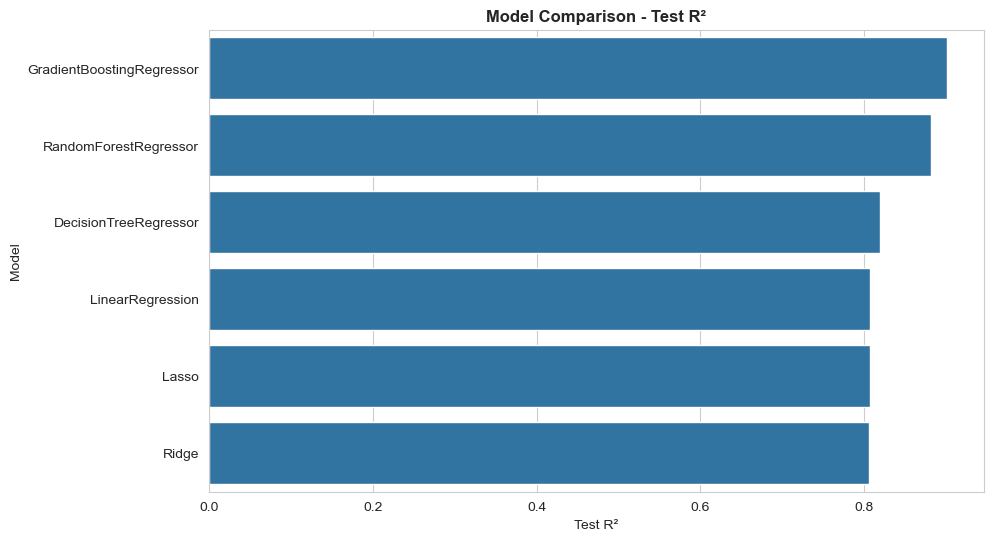

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Test_R2',
    y='Model',
    data=model_comparison_df
)

plt.title('Model Comparison - Test R²', fontweight='bold')
plt.xlabel('Test R²')
plt.ylabel('Model')
plt.show()


**Decision Insight**

Use the evaluation table to compare models. A higher test R² indicates that the model explains more variation in insurance charges, while lower MAE and RMSE indicate smaller prediction errors. The final model should be selected using the test metrics together with cross-validation and overfitting checks.


---
**`🌍 Hyper-Parameter Tuning`**


In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print('Best Parameters:')
print(rf_grid.best_params_)
print('Best CV R²:', rf_grid.best_score_)


Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV R²: 0.842780243427835


---
**`🎯 Final Model Building`**


In [24]:
final_model = rf_grid.best_estimator_

final_model.fit(X_train, y_train)

y_train_predict = final_model.predict(X_train)
y_test_predict = final_model.predict(X_test)

train_r2, train_mae, train_mse, train_rmse = model_evaluation(
    y_train, y_train_predict
)

test_r2, test_mae, test_mse, test_rmse = model_evaluation(
    y_test, y_test_predict
)

print('Training Performance')
print(f'R²   : {train_r2:.4f}')
print(f'MAE  : {train_mae:.2f}')
print(f'MSE  : {train_mse:.2f}')
print(f'RMSE : {train_rmse:.2f}')

print('\nTesting Performance')
print(f'R²   : {test_r2:.4f}')
print(f'MAE  : {test_mae:.2f}')
print(f'MSE  : {test_mse:.2f}')
print(f'RMSE : {test_rmse:.2f}')


Training Performance
R²   : 0.8783
MAE  : 2245.86
MSE  : 16662939.47
RMSE : 4082.03

Testing Performance
R²   : 0.9016
MAE  : 2420.88
MSE  : 18072557.99
RMSE : 4251.18


---
<h3 style='color:orange;font-weight:bold;text-align:center'>Task-2 : Model & Feature Relationships</h3>

- Data split into training and testing sets.
- Baseline and tree-based regression models were compared.
- Hyper-parameter tuning was applied to the Random Forest model.
- Training and testing metrics are used to check model performance and possible overfitting.


---
**`🧪 Model Evaluation with Cross Validation`**


In [25]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    estimator=final_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print('CV Scores:', cv_scores)
print('Mean CV R²:', cv_scores.mean())
print('Std CV R²:', cv_scores.std())


CV Scores: [0.80967484 0.85516521 0.84005764 0.85719547 0.85180805]
Mean CV R²: 0.842780243427835
Std CV R²: 0.017584468361171356


**Model Testing Plots**


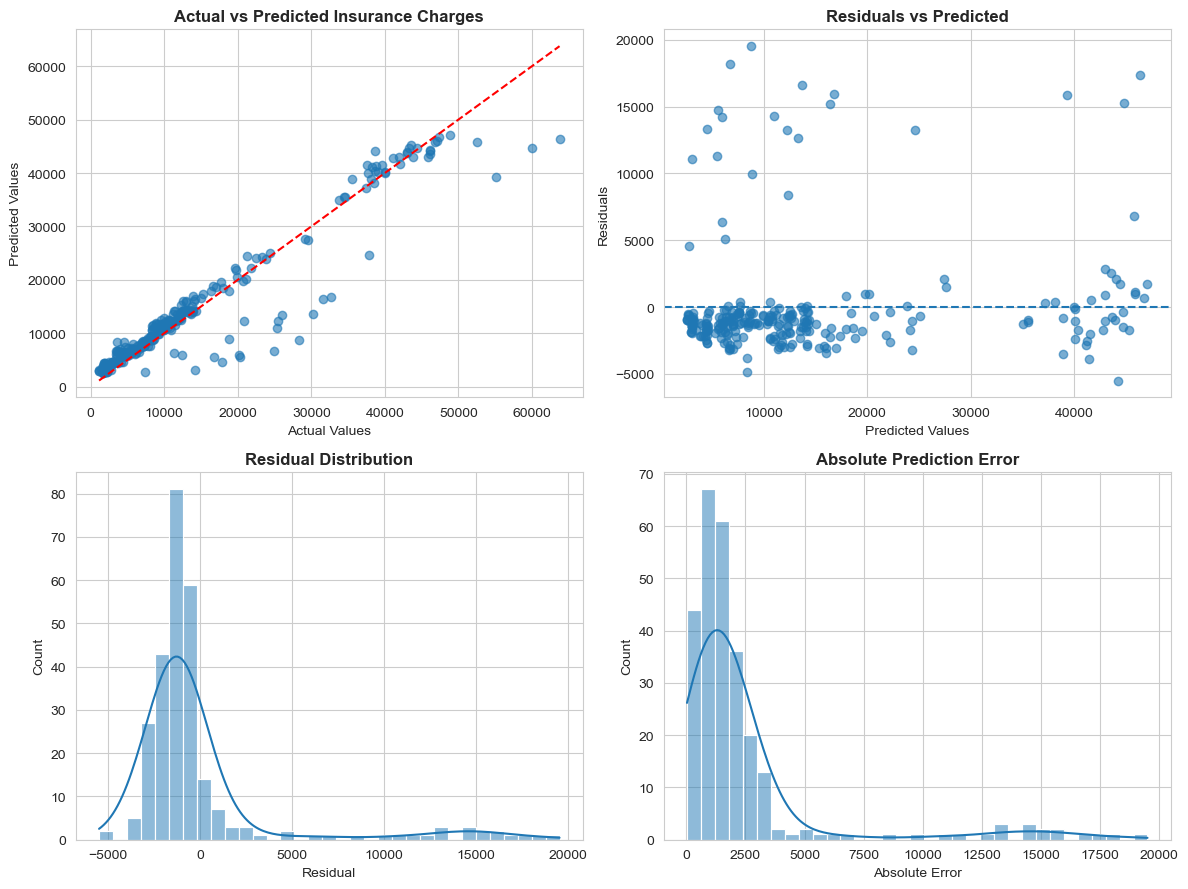

In [26]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
ax = ax.flatten()

# Actual vs Predicted
ax[0].scatter(y_test, y_test_predict, alpha=0.6)
ax[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
ax[0].set_title('Actual vs Predicted Insurance Charges', fontweight='bold')
ax[0].set_xlabel('Actual Values')
ax[0].set_ylabel('Predicted Values')

# Residuals vs Predicted
residuals = y_test - y_test_predict
ax[1].scatter(y_test_predict, residuals, alpha=0.6)
ax[1].axhline(y=0, linestyle='--')
ax[1].set_title('Residuals vs Predicted', fontweight='bold')
ax[1].set_xlabel('Predicted Values')
ax[1].set_ylabel('Residuals')

# Residual distribution
sns.histplot(residuals, kde=True, ax=ax[2])
ax[2].set_title('Residual Distribution', fontweight='bold')
ax[2].set_xlabel('Residual')

# Prediction error
errors = np.abs(residuals)
sns.histplot(errors, kde=True, ax=ax[3])
ax[3].set_title('Absolute Prediction Error', fontweight='bold')
ax[3].set_xlabel('Absolute Error')

plt.tight_layout()
plt.show()


---
**`🔍 Feature Importance`**


,Feature,Importance
4,smoker_yes,0.679948
1,bmi,0.181250
0,age,0.121975
2,children,0.013762
5,region_northwest,0.001232
7,region_southwest,0.000663
6,region_southeast,0.000654
3,sex_male,0.000515


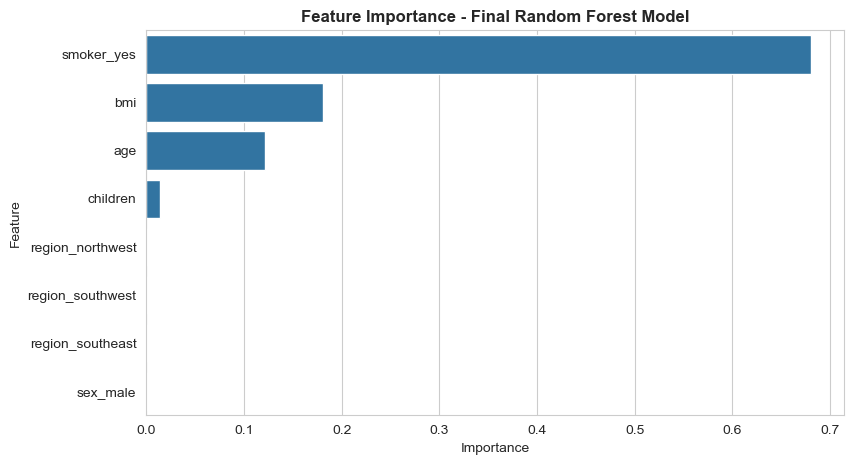

In [27]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

display(feature_importance)

plt.figure(figsize=(9, 5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title('Feature Importance - Final Random Forest Model', fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


---
**`💾 Saving the Model`**


In [28]:
import pickle

with open('insurance_cost_prediction_model.pkl', 'wb') as file:
    pickle.dump(final_model, file)

with open('insurance_cost_features.pkl', 'wb') as file:
    pickle.dump(X.columns.tolist(), file)

print('Model and feature list saved successfully.')


Model and feature list saved successfully.


---
**`🧪 Sample Insurance Cost Prediction`**


In [29]:
# Sample customer
new_customer = pd.DataFrame({
    'age': [30],
    'bmi': [25.5],
    'children': [2],
    'sex_male': [1],
    'smoker_yes': [0],
    'region_northwest': [0],
    'region_southeast': [0],
    'region_southwest': [0]
})

# Align columns exactly with the training features
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

predicted_cost = final_model.predict(new_customer)[0]

print(f'Predicted Insurance Cost: ₹ {predicted_cost:,.2f}')


Predicted Insurance Cost: ₹ 6,281.22


---
<h3 style='color:green;font-weight:bold;text-align:center'>Task 3: Insurance Cost Prediction Insights</h3>

- Age, BMI, smoking status, and other customer characteristics are analyzed to understand insurance-cost variation.
- Model performance is compared using R², MAE, MSE, and RMSE.
- Feature importance helps explain which variables contribute most to the final Random Forest model.
- The trained model can be used to estimate insurance charges for a new customer.


In [31]:
print('PROJECT COMPLETED')
print(f'Final Test R²  : {test_r2:.4f}')
print(f'Final Test MAE : {test_mae:.2f}')
print(f'Final Test RMSE: {test_rmse:.2f}')
print(f'CV Mean R²     : {cv_scores.mean():.4f}')


PROJECT COMPLETED
Final Test R²  : 0.9016
Final Test MAE : 2420.88
Final Test RMSE: 4251.18
CV Mean R²     : 0.8428
